# zeeman slower simulation

# TOOL BOX

In [4]:
import numpy as np
from scipy.constants import hbar, c, pi, e, m_e
from scipy.integrate import odeint
import matplotlib.pyplot as plt

## algorithm:

In [5]:
class ZeemanSlower:
    def __init__(self, gamma, k, mass, mu_eff, wavelength):
        """
        Initialize Zeeman Slower parameters
        """
        self.gamma = gamma
        self.k = k
        self.mass = mass
        self.mu_eff = mu_eff
        self.wavelength = wavelength
        self.gamma_hz = gamma / (2 * np.pi)
        self.hbar = hbar
        self.c = c

    def scattering_force(self, v, z, delta_laser, B_func, s):
        """
        Radiation pressure force
        """
        B = B_func(z)
        delta_total = delta_laser + self.k * v - (self.mu_eff * B / self.hbar)
        scattering_rate = (self.gamma / 2) * (s / (1 + s + (2 * delta_total / self.gamma)**2))
        force = -self.hbar * self.k * scattering_rate

        return force, delta_total, scattering_rate

    def saturation_param(self, z, rho, P_L, wL):
        """
        Saturation parameter s(z, rho)
        """
        I_sat = (np.pi * self.hbar * self.c * self.gamma) / (3 * self.wavelength**3)
        z_R = np.pi * wL**2 / self.wavelength  # rayleigh length
        w_z = wL * np.sqrt(1 + (z / z_R)**2)
        I_0 = 2 * P_L / (np.pi * wL**2)
        I_rho_z = I_0 * (wL / w_z)**2 * np.exp(-2 * rho**2 / w_z**2)
        s = I_rho_z / I_sat
        return s

    def create_B_field_function(self, slower_length, v_i, v_f, delta_laser):
        """
        B-field function with pre-set parameters
        B_func : callable function that takes z and returns B(z)
        """
        def B_func(z):
            return self.ideal_B_field(z, slower_length, v_i, v_f, delta_laser)
        return B_func

    def ideal_B_field(self, z, slower_length, v_i, v_f, delta_laser):
        """
        ideal B-field profile for constant deceleration
        returns B_z: float or array, magnetic field [T] at z
        """
        # Handle both single vals and arrays
        if isinstance(z, np.ndarray):
            B_z = np.zeros_like(z)
            mask = (z >= 0) & (z <= slower_length)
            B_z[mask] = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z[mask] / slower_length)
            )
            B_z[z > slower_length] = (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
        else:
            if z < 0 or z > slower_length:
                return (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
            B_z = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z / slower_length)
            )

        return B_z

    def simulate_slower(self, z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.05, n_points=1000):
        """
        Simulate atom trajectory through Zeeman slower
        """
        initial_state = [z0, v0]  # [position, velocity]
        t = np.linspace(0, t_max, n_points)

        # lists for dynamic storage during simulation
        force_list = []
        delta_total_list = []
        scattering_rate_list = []
        s_list = []
        B_list = []
        z_list = []
        v_list = []
        t_list = []
        rho_list = []

        self.has_exited = False
        self.exit_time = -1
        self.exit_position = -1
        self.exit_velocity = -1

        def motion_equation(state, t):
            z, v = state

            # If atom has left slower, stop simulation
            if z >= slower_length and not self.has_exited:
                self.has_exited = True
                self.exit_time = t
                self.exit_position = z
                self.exit_velocity = v
                raise StopIteration("Atom exited Zeeman Slower")

            # calculate saturation parameter
            s_val = self.saturation_param(z, rho0, P_L, wL)

            # calculate force and acceleration
            force, delta_total, scattering_rate = self.scattering_force(v, z, delta_laser, B_func, s_val)
            acceleration = force / self.mass

            # Store data
            force_list.append(force)
            delta_total_list.append(delta_total)
            scattering_rate_list.append(scattering_rate)
            s_list.append(s_val)
            B_list.append(B_func(z))
            z_list.append(z)
            v_list.append(v)
            rho_list.append(rho0)
            t_list.append(t)
            return [v, acceleration]  # [velocity, acceleration]

        try:
            # solve motion equation
            solution = odeint(motion_equation, initial_state, t, full_output=1)
            z_sol = solution[0][:, 0]
            v_sol = solution[0][:, 1]

            # If we reach here, atom didn't exit within time limit
            actual_length = len(t_list)
            t_actual = np.array(t_list)
            z_actual = np.array(z_list[:actual_length])
            v_actual = np.array(v_list[:actual_length])
            rho_actual = np.array(rho_list[:actual_length])

        except StopIteration:
            # atom exited, use stored data
            actual_length = len(t_list)
            t_actual = np.array(t_list)
            z_actual = np.array(z_list)
            v_actual = np.array(v_list)
            rho_actual = np.array(rho_list)

        # store results as class attributes
        actual_length = len(t_actual)
        self.force_history = np.array(force_list[:actual_length])
        self.delta_total_history = np.array(delta_total_list[:actual_length])
        self.scattering_rate_history = np.array(scattering_rate_list[:actual_length])
        self.s_history = np.array(s_list[:actual_length])
        self.B_history = np.array(B_list[:actual_length])

        return t_actual, z_actual, v_actual, rho_actual

    def analyze_saturation_profile(self, z_range, rho_range, P_L, wL):
        """
        saturation parameter profile along the slower
        """
        Z, RHO = np.meshgrid(z_range, rho_range)
        S = np.zeros_like(Z)

        for i in range(len(z_range)):
            for j in range(len(rho_range)):
                S[j, i] = self.saturation_param(z_range[i], rho_range[j], P_L, wL)

        return Z, RHO, S


## single atom:

Testing B-field function:
B at z=0: 19.8 mT
B at end: -33.9 mT

Running simulation...

Simulation results:
Initial velocity: 350.0 m/s
Final velocity: 37.2 m/s
Velocity reduction: 312.8 m/s (89.4%)
Exit status: Exited
Saturation range: 6.676 - 6.676
Maximun scattering rate: 79.0 MHz
Maximum saturation: 6.676
Travel distance: 18.0 cm
Travel time: 1.0 ms


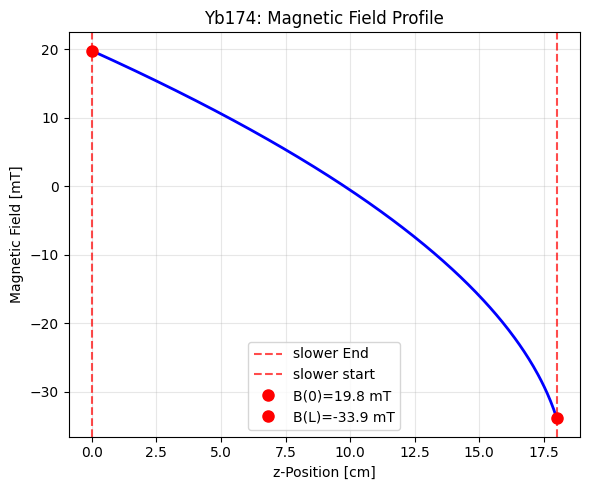

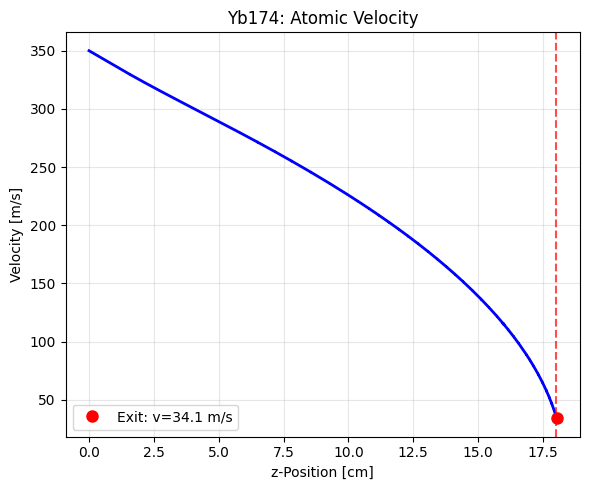

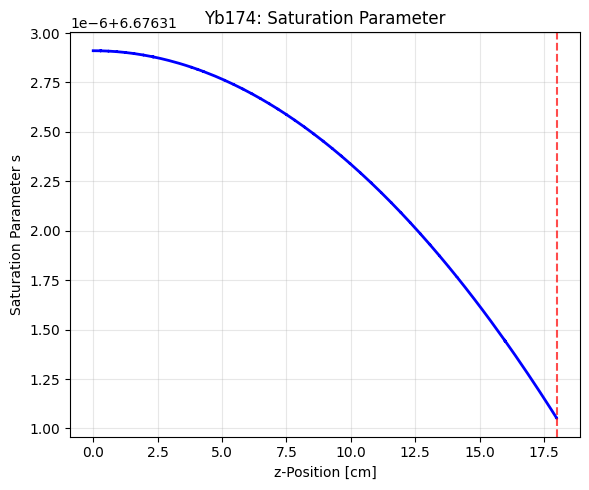

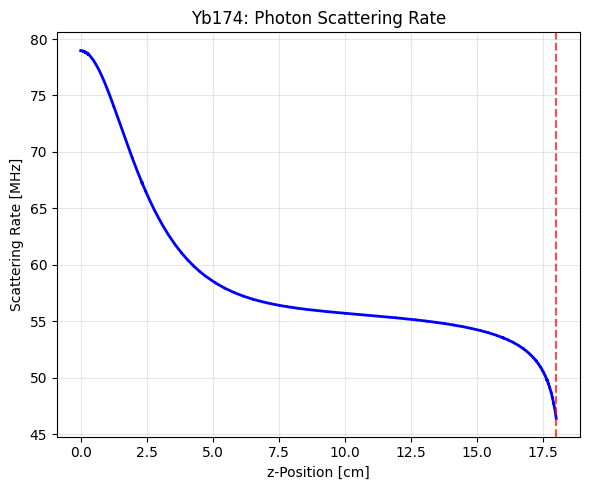

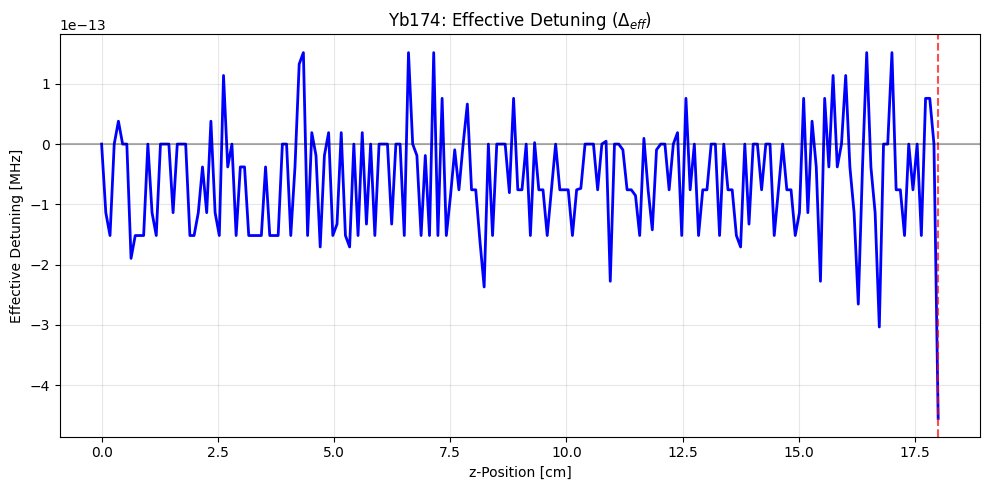

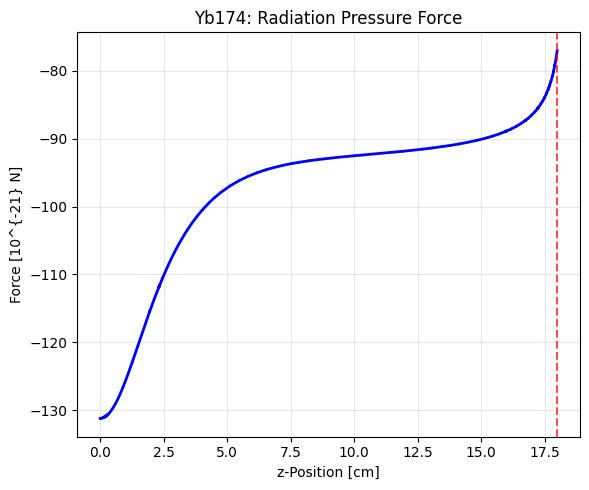

In [3]:
# single atom example

if __name__ == "__main__":

    # Yb174 parameters
    au = 1.66053906660e-27 # kg
    m_174 = 174 * au
    Gamma_399 = 2* np.pi *28.9e6  # [rad/s]
    lmd_399 = 398.9e-9
    k_399 = 2 * np.pi / lmd_399

    g_e, g_g = 1.0, 0.0     # correct for 174Yb (1P1 -> 1S0)
    M_e, M_g = 1, 0         # sigma - cycling transition
    mu_B = e * hbar / (2 * m_e)
    mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T]

    # create slower instance
    slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)

    z0 = 0.0
    rho0 = 0.001    # 1mm radial offset
    v0 = 350.0      # initial velocity m/s
    delta_laser = 2 * np.pi * (-600) * 1e6 # rad/s
    P_L = 44e-3     # laser power [W]
    wL = 6.5e-3     # laser waist [m]
    slower_length = 0.18  # m
    v_final = 50.0  # m/s

    # create B-field function using the new method
    B_func = slower.create_B_field_function(slower_length, v0, v_final, delta_laser)
    
    print("Testing B-field function:")
    print(f"B at z=0: {B_func(0)*1000:.1f} mT")
    print(f"B at end: {B_func(slower_length)*1000:.1f} mT")

    print(f"\nRunning simulation...")
    t, z, v, rho = slower.simulate_slower(z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.02)
    print(f"\nSimulation results:")
    print(f"Initial velocity: {v0:.1f} m/s")
    print(f"Final velocity: {v[-1]:.1f} m/s")
    print(f"Velocity reduction: {v0 - v[-1]:.1f} m/s ({((v0 - v[-1])/v0*100):.1f}%)")
    print(f"Exit status: {'Exited' if slower.has_exited else 'Time limit'}")
    print(f"Saturation range: {slower.s_history.min():.3f} - {slower.s_history.max():.3f}")
    print(f"Maximun scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {slower.s_history.max():.3f}")
    print(f"Travel distance: {z[-1]*100:.1f} cm")
    print(f"Travel time: {t[-1]*1000:.1f} ms")


# Yb174 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title('Yb174: Magnetic Field Profile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
plt.plot(z * 100, v, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
if slower.has_exited:
  exit_z = slower.exit_position * 100
  exit_v = slower.exit_velocity
  plt.plot(exit_z, exit_v, 'ro', markersize=8, label=f'Exit: v={exit_v:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title('Yb174: Atomic Velocity')
plt.grid(True, alpha=0.3)
if slower.has_exited:
  plt.legend()
plt.tight_layout()
plt.show()

# 3. Saturation parameter along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.s_history, 'blue', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Saturation Parameter s')
plt.title('Yb174: Saturation Parameter')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Photon scattering rate along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.scattering_rate_history / 1e6, 'blue', linewidth=2)
plt.axvline(x = slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Scattering Rate [MHz]')
plt.title('Yb174: Photon Scattering Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. effective detuning
plt.figure(figsize=(10, 5))
z_detailed = np.linspace(0, slower_length, 200)
B_detailed = B_func(z_detailed)
# calculate required B-field for resonance (const deceleration)
v_resonance = np.sqrt(v0**2 + (v_final**2 - v0**2) * z_detailed / slower_length)
delta_effective = delta_laser + slower.k * v_resonance - (slower.mu_eff * B_detailed / slower.hbar)
plt.plot(z_detailed * 100, delta_effective / (2 * np.pi * 1e6), 'b-', linewidth=2)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title('Yb174: Effective Detuning ($\Delta_{eff}$)')
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
plt.plot(z * 100, slower.force_history * 1e21, 'b-', linewidth=2)  # Scale for better visibility
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title('Yb174: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TEST计算

## 5000 atoms:

3D maxwellian velocity distribution: where $v_p = \sqrt{2k_BT/m}$
$$f(v) = \frac{4}{\sqrt{\pi}} \left(\frac{v^2}{v_p^3} \right) \exp\left( -\frac{v^2}{v_p^2} \right)$$

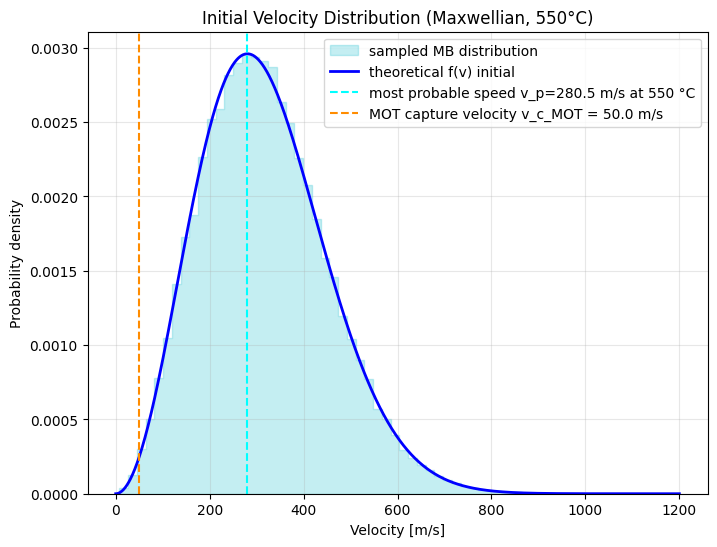

In [58]:
# 覆盖参数 parameters for 5000
n_samples = 50000
celcius = 550
T = 273.15 + celcius
k_B = 1.380649e-23
v_p = np.sqrt(2*k_B*T/m_174)
v_c_MOT = 50

# for initial f(v) distribution
def maxwell_pdf(v, T, m):
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    sigma = np.sqrt(k_B*T/m)
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)

# generate initial velocities and theoretical PDF
initial_velocities = sample_maxwell(T, m_174, n_samples)
v_range = np.linspace(0, 1200, 1000)
f_v_initial = maxwell_pdf(v_range, T, m_174)

# plot initial velocity distribution and theoretical f(v) PDF
plt.figure(figsize=(8, 6))
plt.hist(initial_velocities, bins=50,density=True,histtype="stepfilled",color="tab:cyan", alpha=0.25,edgecolor="tab:cyan", linewidth=1, label="sampled MB distribution")
plt.plot(v_range, f_v_initial, 'b-', linewidth=2, label="theoretical f(v) initial")
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {celcius} °C")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Initial Velocity Distribution (Maxwellian, {celcius}°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [59]:
# number density: generate radial positions for Gaussian atomic beam

w_a = 5e-3   # atomic beam waist 5mm / diameter 10mm

def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(initial_velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(initial_velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(initial_velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

for the Yb atomic beam - 
  Most probable speed: v_p = 280.48 m/s
  RMS velocity: v_rms = 343.59 m/s
  Mean velocity: 316.69 m/s
  Standard deviation: 133.26 m/s
  Atom Beam waist: w_a = 5.0 mm 



## Exp data

In [69]:
# scan multiple laser powers and store each result set
P_L_list = [0, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
# new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)
# simulate for when there's no magnetic field
new_B_func = lambda z: np.zeros_like(z)
delta_laser = -600 * 1e6 * 2 * np.pi
wL = 6.5e-3
slower_length = 0.2

I_sat_399 = 60 # mW/cm^2
I_list = 2*np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s:")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s:
  P_L = 0.00 mW -> s = 0.00
  P_L = 1.00 mW -> s = 0.03
  P_L = 2.00 mW -> s = 0.05
  P_L = 3.00 mW -> s = 0.08
  P_L = 4.00 mW -> s = 0.10
  P_L = 5.00 mW -> s = 0.13
  P_L = 6.00 mW -> s = 0.15
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 206 (0.4%)
Final velocity statistics:
  Mean: 316.69 m/s
  Std: 133.26 m/s
  Min: 7.85 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 1.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 207 (0.4%)
Final velocity statistics:
  Mean: 315.22 m/s
  Std: 134.14 m/s
  Min: 7.58 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 2.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 207 (0.4%)
Final velocity statistics:
  Mean: 314.23 m/s
  Std: 134.75 m/s
  Min: 7.31 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 3.00 mW) ===
Total atoms simula

In [61]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

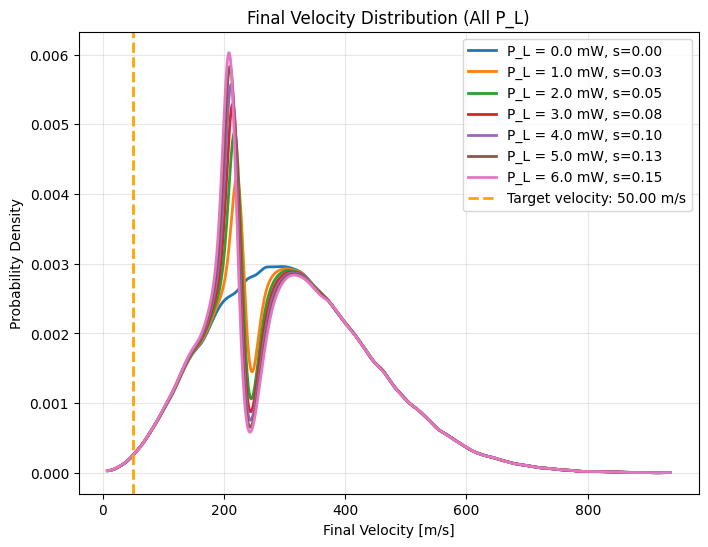

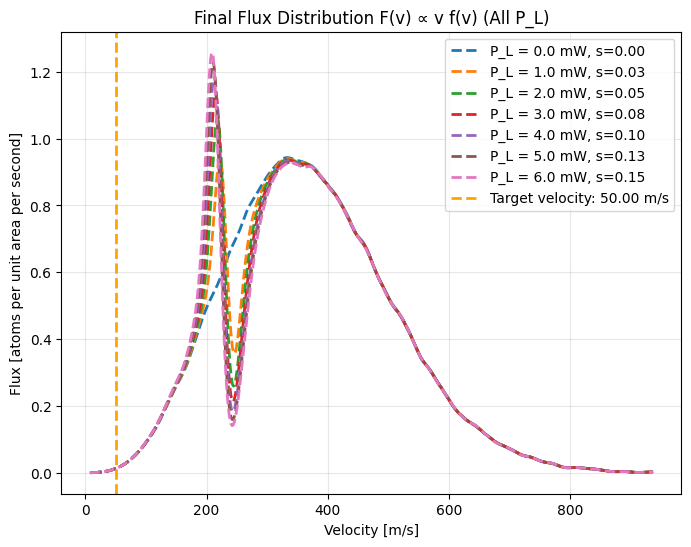

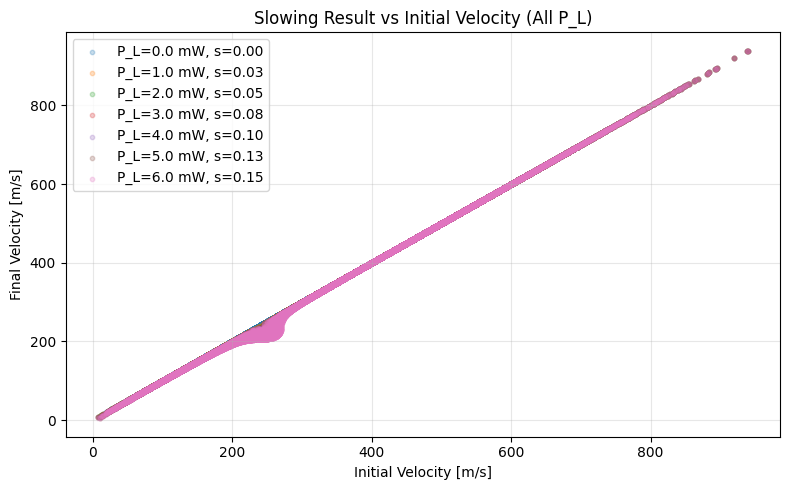

In [70]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

# 1) FINAL velocity distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) final flux distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# # 3) INITIAL velocity distribution (for comparison)
# plt.figure(figsize=(8, 6))
# plt.hist(initial_velocities, bins=50, density=True, alpha=0.35, color='cyan', label='Initial f(v) sampled')
# plt.plot(v_range_initial, f_v_initial(v_range_initial), 'r-', linewidth=2, label='Initial f(v) smoothed')
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Initial Velocity [m/s]')
# plt.ylabel('Probability Density')
# plt.title('Initial Velocity Distribution')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 4) initial flux distribution
# plt.figure(figsize=(8, 6))
# mask = v_range_initial > 0
# plt.plot(v_range_initial[mask], flux_initial[mask], 'r--', linewidth=2, label='Initial flux distribution')
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Flux [atoms per unit area per second]')
# plt.title('Initial Flux Distribution F(v) ∝ v f(v)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# 5) comparison: initial vs all final f(v)
# v_range_compare = np.linspace(-200, 1000, 1000)
# plt.figure(figsize=(8, 6))
# plt.plot(v_range_compare, f_v_initial(v_range_compare), 'k-', linewidth=2, label='Initial f(v)')
# for i, P_L in enumerate(P_L_list):
#     label = f'Final f(v), P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
#     plt.plot(v_range_compare, f_v_final_list[i](v_range_compare), linewidth=2, label=label)
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Probability Density')
# plt.title('Initial vs Final Velocity Distributions (All P_L)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 6) comparison: initial flux vs all final flux
# plt.figure(figsize=(8, 6))
# plt.plot(v_range_initial, flux_initial, 'k--', linewidth=2, label='Initial flux distribution')
# for i, P_L in enumerate(P_L_list):
#     label = f'Final flux, P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
#     plt.plot(v_range_final_list[i], flux_final_list[i], '--', linewidth=2, label=label)
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Flux [atoms per unit area per second]')
# plt.title('Initial vs Final Flux Distributions (All P_L)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 7) designed B-field (annotated by all P_L)
# plt.figure(figsize=(6, 5))
# z_plot = np.linspace(0, slower_length, 300)
# B_plot = new_B_func(z_plot)
# for i, P_L in enumerate(P_L_list):
#     plt.plot(z_plot * 100, B_plot * 1e3, linewidth=2, label=f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}')
# plt.axvline(x=slower_length * 100, color='b', linestyle='--', alpha=0.7, label='Slower end')
# plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Slower start')
# plt.xlabel('z-Position [cm]')
# plt.ylabel('Magnetic Field [mT]')
# plt.title(f'Designed Magnetic Field Profile ({n_samples} atoms)')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# 8) success vs initial velocity for all P_L
plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## fluorescence:
$$F(\Delta) = \int f(v) R_{sc}(\Delta + kv) dv$$
$$R_{sc}​(\Delta) = \frac{\Gamma}{2} \frac{s}{1+s+(2\Delta/\Gamma)^2}$$

In [92]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 100 # mW
w_556 = 0.05 # cm
I_556 = 2 * P_556 / (pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 181891.36


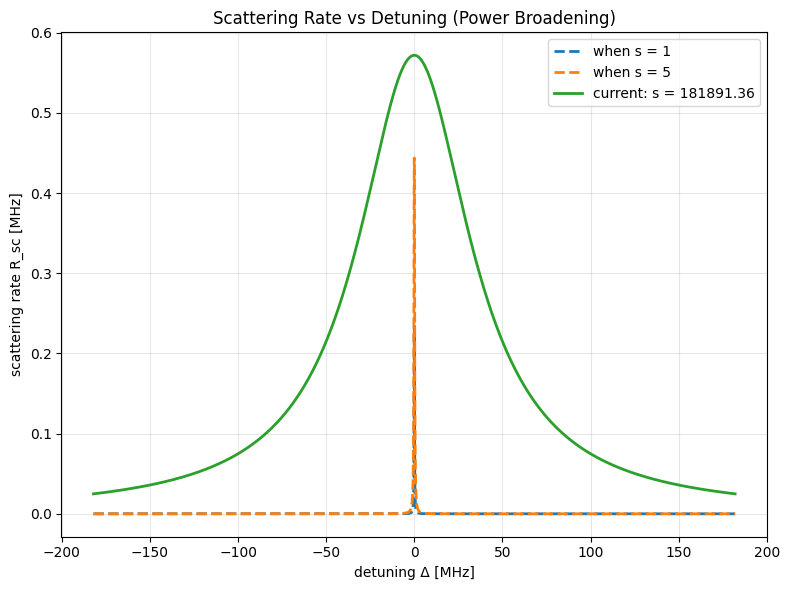

In [93]:
delta_range = np.linspace(-1000 * Gamma_556, 1000 * Gamma_556, 3000)

def R_sc(delta, s):
    return (Gamma_556/2) * (s / (1 + s + (2*delta/Gamma_556)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_556)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_556:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



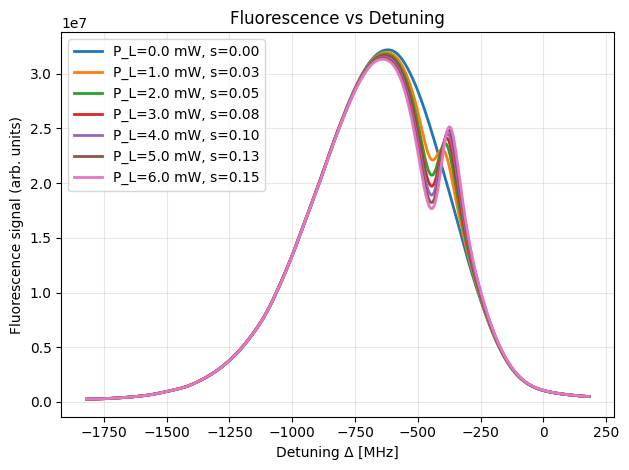

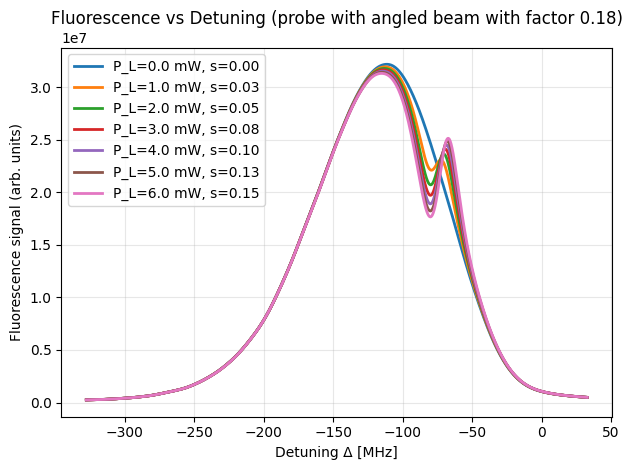

In [94]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


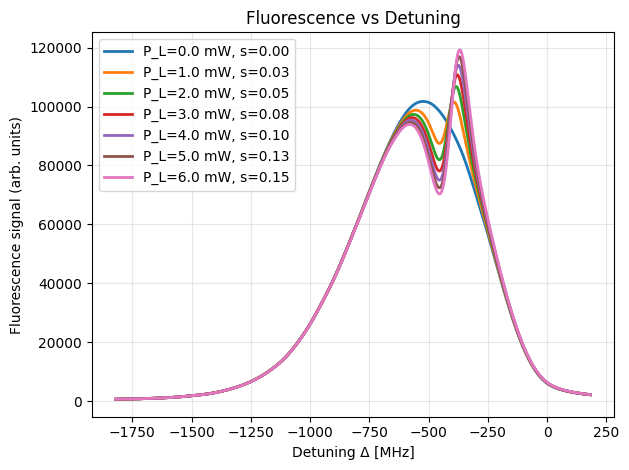

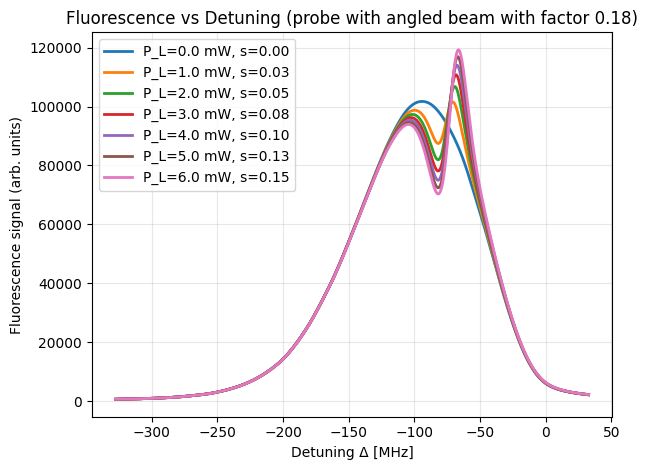

In [95]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 解相儒的计算

## 5000 atoms:

3D maxwellian velocity distribution: where $v_p = \sqrt{2k_BT/m}$
$$f(v) = \frac{4}{\sqrt{\pi}} \left(\frac{v^2}{v_p^3} \right) \exp\left( -\frac{v^2}{v_p^2} \right)$$

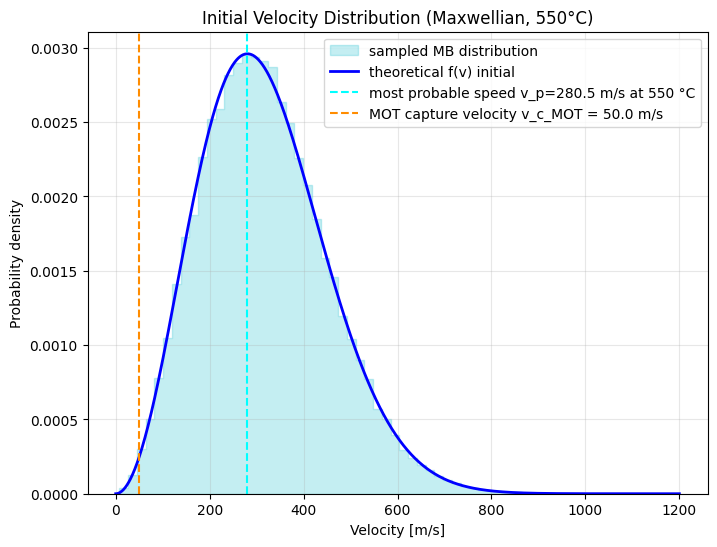

In [ ]:
# 覆盖参数 parameters for 5000
n_samples = 50000
celcius = 550
T = 273.15 + celcius
k_B = 1.380649e-23
v_p = np.sqrt(2*k_B*T/m_174)
v_c_MOT = 50

# for initial f(v) distribution
def maxwell_pdf(v, T, m):
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    sigma = np.sqrt(k_B*T/m)
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)

# generate initial velocities and theoretical PDF
initial_velocities = sample_maxwell(T, m_174, n_samples)
v_range = np.linspace(0, 1200, 1000)
f_v_initial = maxwell_pdf(v_range, T, m_174)

# plot initial velocity distribution and theoretical f(v) PDF
plt.figure(figsize=(8, 6))
plt.hist(initial_velocities, bins=50,density=True,histtype="stepfilled",color="tab:cyan", alpha=0.25,edgecolor="tab:cyan", linewidth=1, label="sampled MB distribution")
plt.plot(v_range, f_v_initial, 'b-', linewidth=2, label="theoretical f(v) initial")
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {celcius} °C")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Initial Velocity Distribution (Maxwellian, {celcius}°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# number density: generate radial positions for Gaussian atomic beam

w_a = 5e-3   # atomic beam waist 5mm / diameter 10mm

def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(initial_velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(initial_velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(initial_velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

for the Yb atomic beam - 
  Most probable speed: v_p = 280.48 m/s
  RMS velocity: v_rms = 343.59 m/s
  Mean velocity: 316.69 m/s
  Standard deviation: 133.26 m/s
  Atom Beam waist: w_a = 5.0 mm 



## Exp data

In [ ]:
# scan multiple laser powers and store each result set
P_L_list = [0,  6e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
# new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)
# simulate for when there's no magnetic field
new_B_func = lambda z: np.zeros_like(z)
delta_laser = -200 * 1e6 * 2 * np.pi
wL = 6.5e-3
slower_length = 0.2

I_sat_399 = 60 # mW/cm^2
I_list = 2*np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s:")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s:
  P_L = 0.00 mW -> s = 0.00
  P_L = 6.00 mW -> s = 0.15
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 199 (0.4%)
Final velocity statistics:
  Mean: 316.94 m/s
  Std: 133.10 m/s
  Min: 8.06 m/s
  Max: 1076.39 m/s

=== Simulation Results (P_L = 6.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 1998 (4.0%)
Final velocity statistics:
  Mean: 313.69 m/s
  Std: 138.78 m/s
  Min: -27.07 m/s
  Max: 1076.39 m/s



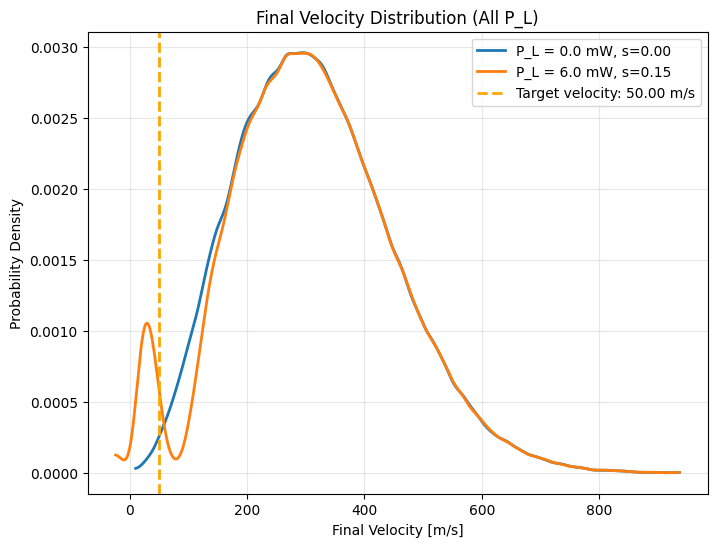

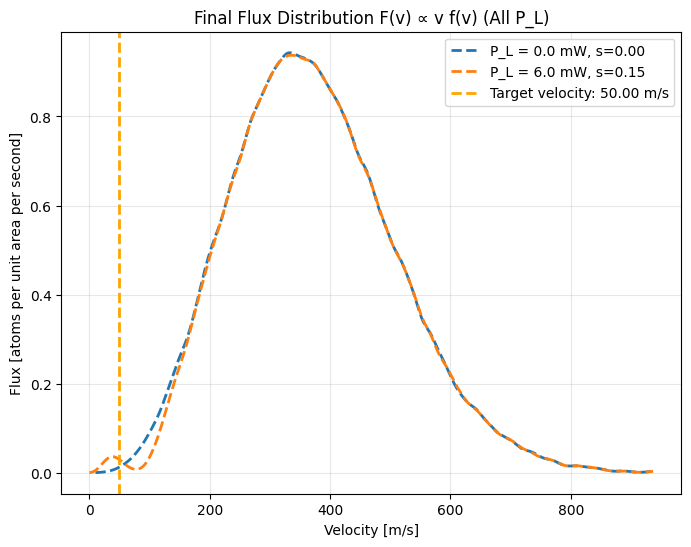

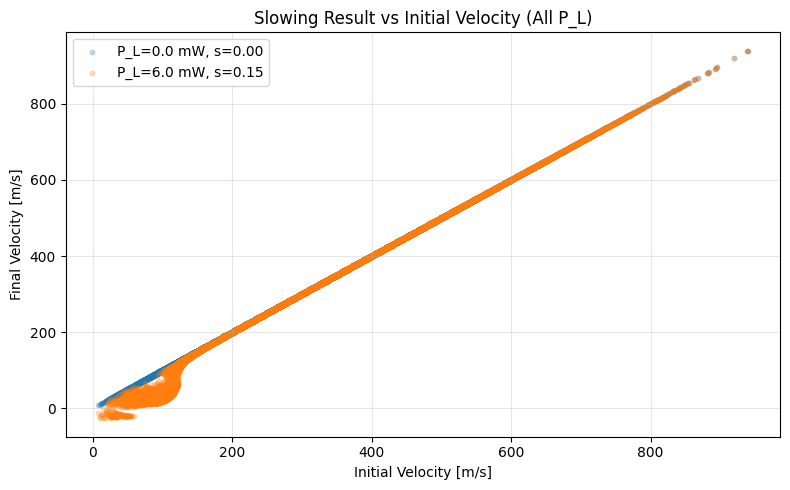

In [ ]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## fluorescence:
$$F(\Delta) = \int f(v) R_{sc}(\Delta + kv) dv$$
$$R_{sc}​(\Delta) = \frac{\Gamma}{2} \frac{s}{1+s+(2\Delta/\Gamma)^2}$$

### 556 probe

In [ ]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 10 # mW
w_556 = 0.3 # cm
I_556 = 2 * P_556 / (pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 505.25


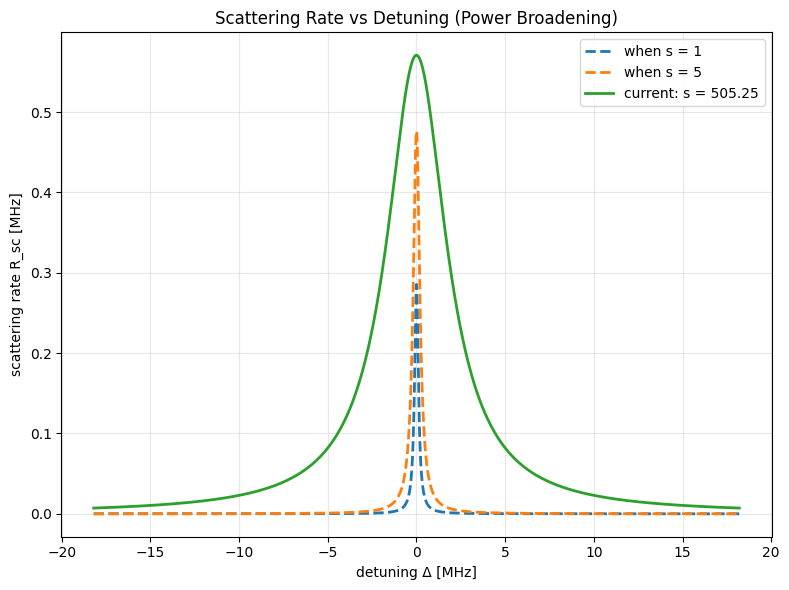

In [ ]:
delta_range = np.linspace(-100 * Gamma_556, 100 * Gamma_556, 3000)

def R_sc(delta, s):
    return (Gamma_556/2) * (s / (1 + s + (2*delta/Gamma_556)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_556)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_556:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



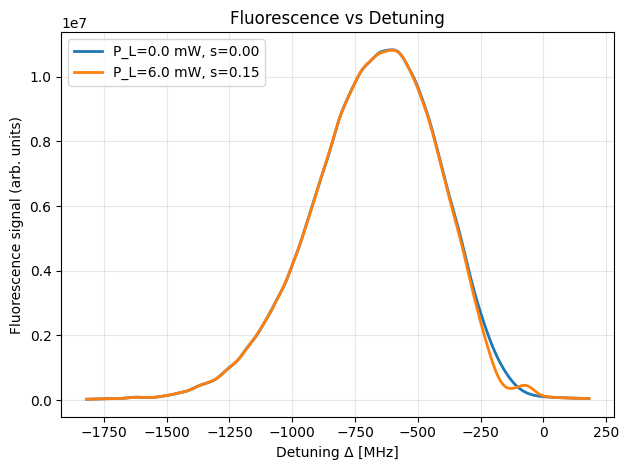

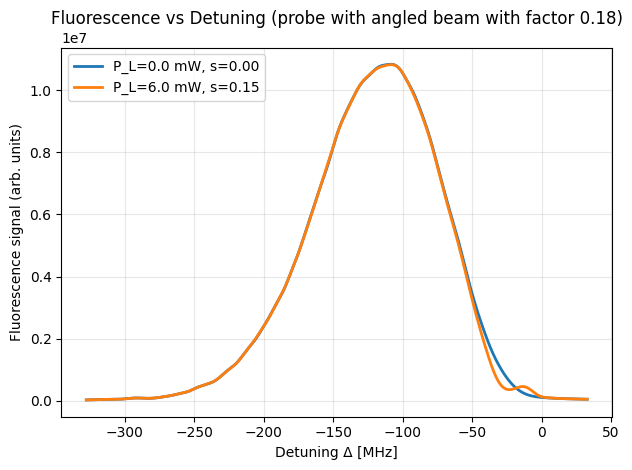

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


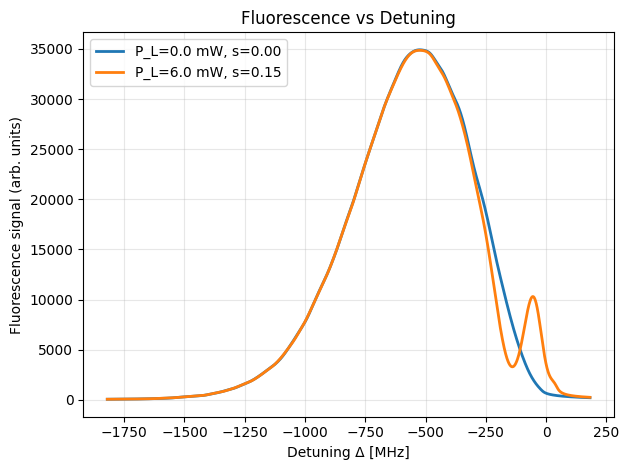

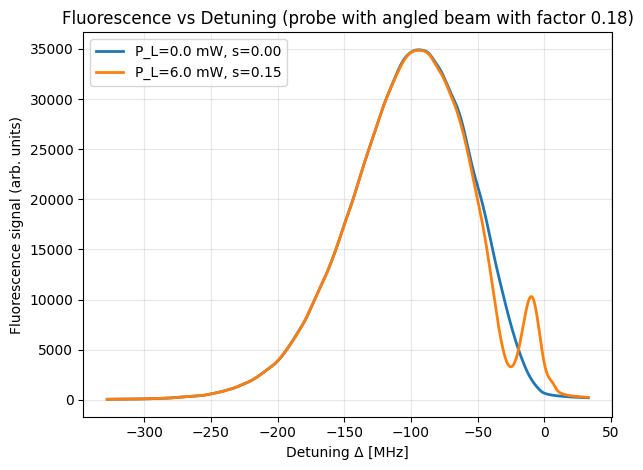

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 399 probe

In [ ]:
Gamma_399 = 2 * np.pi * 29e6  # [rad/s]
k_399 = 2 * np.pi / 399e-9
I_sat_399 = 60 # mW/m^2
P_399 = 0.1 # mW
w_399 = 0.05 # cm
I_399 = 2 * P_399 / (pi * (w_399)**2) # mW/cm^2
s_399 = I_399 / I_sat_399
print(f"399nm transition saturation parameter: s = {s_399:.2f}")

399nm transition saturation parameter: s = 0.42


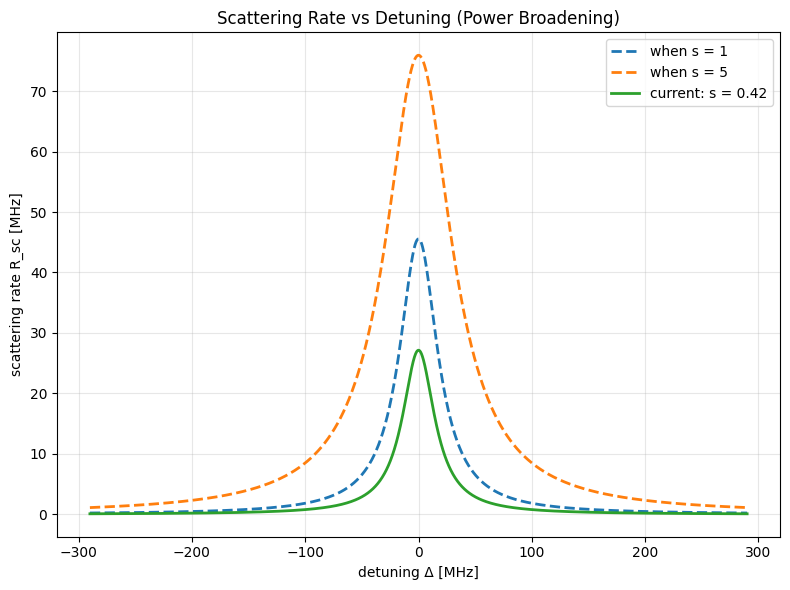

In [ ]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



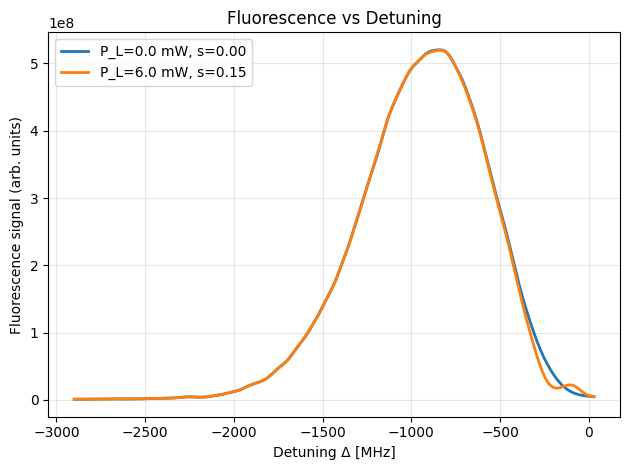

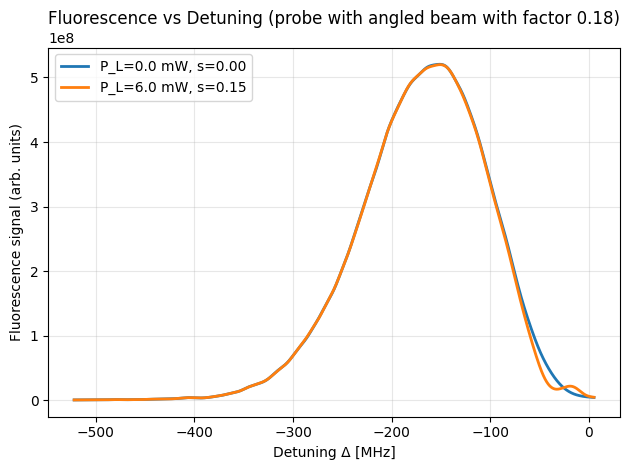

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-100 * Gamma_399, 1 * Gamma_399, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_399 * v_grid_i
        R_vals = R_sc(delta_eff, s_399)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


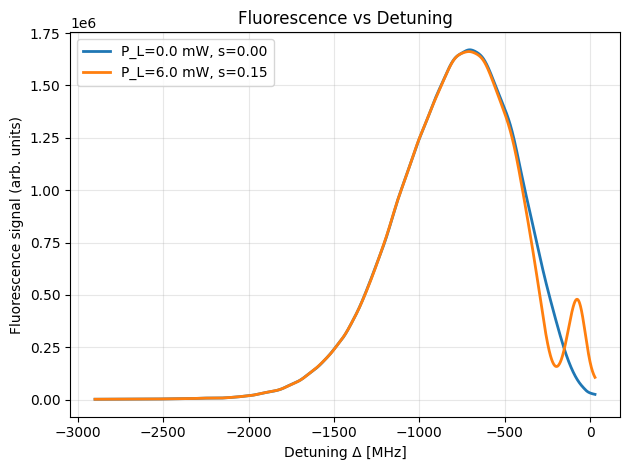

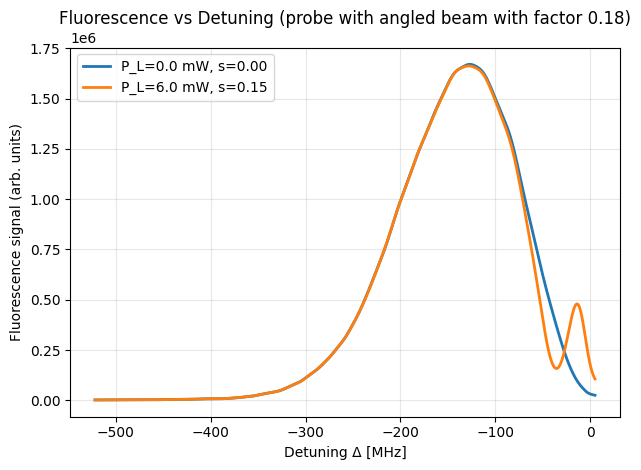

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-100 * Gamma_399, 1 * Gamma_399, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_399 * v_grid_i
        R_vals = R_sc(delta_eff, s_399)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()